In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [14]:

# import
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split # 데이터 분할(층화추출로)
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt # 학습과정 시각화

# 1. 기본적인 dnn

In [15]:

from sklearn import datasets
iris = datasets.load_iris()
# iris.keys()
iris_X = iris.data
iris_y = iris.target # 라벨인코딩이 되어 있음
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                   test_size=0.1,
                                                   stratify=iris_y,
                                                   random_state=4)
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((135, 4), (135,), (15, 4), (15,))

In [16]:
# 모델 설정
# model = Sequential()
# model.add(Input(4,))
# model.add(Dense(units=50, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=3, activation='softmax'))
model = Sequential([
    Input(4,),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax')
])
model.summary() # 250+1530+93 = 1873개 파라미터

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                250       
                                                                 
 dense_1 (Dense)             (None, 30)                1530      
                                                                 
 dense_2 (Dense)             (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [19]:
# 학습설정
model.compile(loss='sparse_categorical_crossentropy', # 라벨인코딩만 되어 있는 경우
             optimizer='adam',
             metrics=['accuracy'])
# 학습
earlyStropping = EarlyStopping(patience=50) # monitor='val_loss' 기본값
hist = model.fit(train_X, train_y, epochs=1000,
                validation_split=0.2,
                callbacks=[earlyStropping])

Epoch 1/1000
4/4 [==============================] - 1s 64ms/step - loss: 1.3140 - accuracy: 0.3426 - val_loss: 1.1560 - val_accuracy: 0.2963
Epoch 2/1000
4/4 [==============================] - 0s 12ms/step - loss: 1.1539 - accuracy: 0.3426 - val_loss: 1.0995 - val_accuracy: 0.2963
Epoch 3/1000
4/4 [==============================] - 0s 11ms/step - loss: 1.0732 - accuracy: 0.3519 - val_loss: 1.0955 - val_accuracy: 0.2593
Epoch 4/1000
4/4 [==============================] - 0s 11ms/step - loss: 1.0415 - accuracy: 0.3796 - val_loss: 1.0955 - val_accuracy: 0.2222
Epoch 5/1000
4/4 [==============================] - 0s 11ms/step - loss: 1.0221 - accuracy: 0.3611 - val_loss: 1.0819 - val_accuracy: 0.2222
Epoch 6/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.9998 - accuracy: 0.3611 - val_loss: 1.0571 - val_accuracy: 0.2222
Epoch 7/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.9725 - accuracy: 0.3981 - val_loss: 1.0225 - val_accuracy: 0.4815
Epoch 8/1000


Epoch 59/1000
4/4 [==============================] - 0s 13ms/step - loss: 0.2230 - accuracy: 0.9907 - val_loss: 0.1751 - val_accuracy: 0.9630
Epoch 60/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.2165 - accuracy: 0.9907 - val_loss: 0.1752 - val_accuracy: 0.9630
Epoch 61/1000
4/4 [==============================] - 0s 13ms/step - loss: 0.2171 - accuracy: 0.9722 - val_loss: 0.1819 - val_accuracy: 0.9630
Epoch 62/1000
4/4 [==============================] - 0s 13ms/step - loss: 0.2089 - accuracy: 0.9722 - val_loss: 0.1676 - val_accuracy: 0.9630
Epoch 63/1000
4/4 [==============================] - 0s 13ms/step - loss: 0.2029 - accuracy: 0.9722 - val_loss: 0.1595 - val_accuracy: 0.9630
Epoch 64/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1968 - accuracy: 0.9815 - val_loss: 0.1592 - val_accuracy: 0.9630
Epoch 65/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1927 - accuracy: 0.9722 - val_loss: 0.1569 - val_accuracy: 0.9630
Epoch 

4/4 [==============================] - 0s 12ms/step - loss: 0.0722 - accuracy: 0.9907 - val_loss: 0.0675 - val_accuracy: 0.9630
Epoch 174/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0727 - accuracy: 0.9907 - val_loss: 0.0690 - val_accuracy: 0.9630
Epoch 175/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0719 - accuracy: 0.9907 - val_loss: 0.0704 - val_accuracy: 0.9630
Epoch 176/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0732 - accuracy: 0.9907 - val_loss: 0.0709 - val_accuracy: 0.9630
Epoch 177/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0720 - accuracy: 0.9907 - val_loss: 0.0685 - val_accuracy: 0.9630
Epoch 178/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0717 - accuracy: 0.9907 - val_loss: 0.0675 - val_accuracy: 0.9630
Epoch 179/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0707 - accuracy: 0.9907 - val_loss: 0.0677 - val_accuracy: 0.9630
Epoch 180/1000

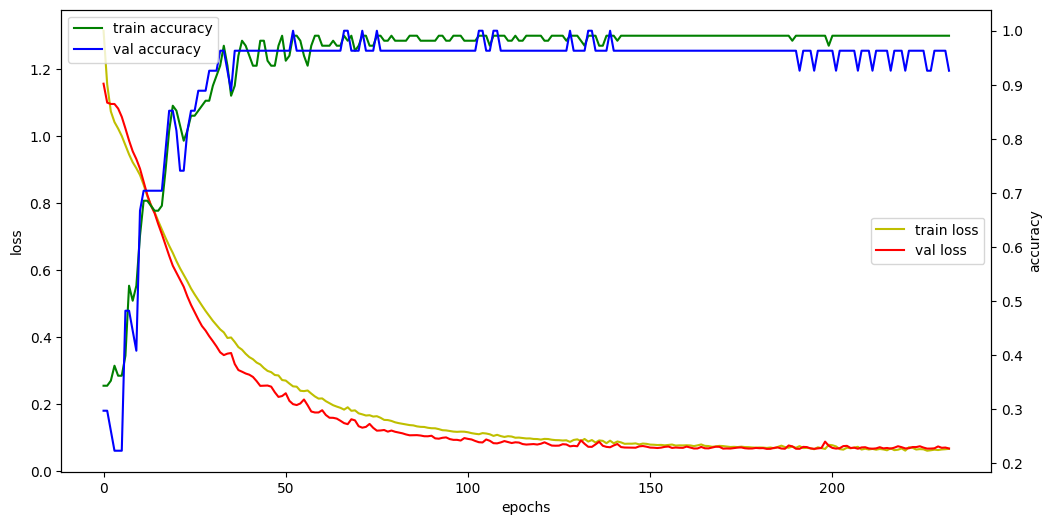

In [20]:
# 5. 모델 학습과정 시각화
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend(loc='upper left')
plt.show()

# 2. sklearn
- 원핫이코딩을 하지 않고 라벨인코딩까지만 해야 작동

In [23]:
# 머신러닝 3장 
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(hidden_layer_sizes=(50,30),
                     activation='relu',
                     solver = 'adam',
                     alpha=0.0001,
                     batch_size=40,
                     max_iter=1000,
                     early_stopping=True,
                     n_iter_no_change=50,
                     validation_fraction=0.1)

In [25]:
mlp_model.fit(train_X, train_y)

MLPClassifier(batch_size=40, early_stopping=True, hidden_layer_sizes=(50, 30),
              max_iter=1000, n_iter_no_change=50)

In [33]:
# 모델평가
from sklearn.metrics import recall_score, precision_score
accuracy = mlp_model.score(test_X, test_y)
yhat = mlp_model.predict(test_X)
recall = recall_score(test_y, yhat, average='weighted')
precision = precision_score(test_y, yhat, average='weighted')
print(accuracy)
print(recall)
print(precision)
print(pd.crosstab(test_y, yhat,
                 rownames=['실제'],
                 colnames=['예측']))

0.9333333333333333
0.9333333333333333
0.9444444444444445
예측  0  1  2
실제         
0   5  0  0
1   0  4  1
2   0  0  5


## 3.클래스 이용

In [40]:
class DNNClassifier:
    @staticmethod
    def build(input_dim=4, activation='relu', optimizer='adam'):
        # 모델 구성
#         model = Sequential()
#         model.add(Input(input_dim,))
#         model.add(Dense(50, activation=activation))
#         model.add(Dense(30, activation=activation))
#         model.add(Dense(3, activation='softmax'))
        model = Sequential([
            Input(input_dim,) ,
            Dense(50, activation=activation),
            Dense(30, activation=activation),
            Dense(3, activation='softmax')
        ])
        # 모델 학습 설정
        model.compile(loss='sparse_categorical_crossentropy',
                     optimizer=optimizer,
                     metrics=['accuracy'])
        return model

In [44]:
model = DNNClassifier.build(input_dim=4, activation='relu')
model.summary()
hist = model.fit(train_X, train_y,
                epochs=500,
                validation_split=0.2,
                verbose=0)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 50)                250       
                                                                 
 dense_8 (Dense)             (None, 30)                1530      
                                                                 
 dense_9 (Dense)             (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


# 4. 함수형 api 이용하기

In [53]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split # 데이터 분할(층화추출로)
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.layers import concatenate # 병렬처리
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt # 학습과정 시각화
from tensorflow.keras import Model

In [54]:
from sklearn import datasets
iris = datasets.load_iris()
# iris.keys()
iris_X = iris.data
iris_y = iris.target # 라벨인코딩이 되어 있음
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                   test_size=0.1,
                                                   stratify=iris_y,
                                                   random_state=4)
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((135, 4), (135,), (15, 4), (15,))

In [55]:
# 기존의 model 스타일 4 -> 50 -> 30 -> 3
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=30, activation='relu')(dense1)
dense3 = Dense(units=3, activation='softmax')(dense2)
model = Model(inputs=input_, outputs=dense3)
model.summary()
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
model.fit(train_X, train_y, epochs=20,
         validation_split=0.2)


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_11 (InputLayer)       [(None, 4)]               0         
                                                                 
 dense_26 (Dense)            (None, 50)                250       
                                                                 
 dense_27 (Dense)            (None, 30)                1530      
                                                                 
 dense_28 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
4/4 [==============================] - 1s 51ms/step - loss: 3.2143 - accuracy: 0.2963 - val_loss: 1.9434 - val_accuracy: 0.4815
Epoch 2/20
4/4 [==============================] - 0s

In [57]:
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=80, activation='relu')(input_)
dense3 = Dense(units=30, activation='relu')(input_)
x = concatenate([dense1, dense2, dense3])
dense4 = Dense(32, activation='relu')(x)
output = Dense(3, activation='softmax')(dense4)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_13 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_32 (Dense)               (None, 50)           250         ['input_13[0][0]']               
                                                                                                  
 dense_33 (Dense)               (None, 80)           400         ['input_13[0][0]']               
                                                                                                  
 dense_34 (Dense)               (None, 30)           150         ['input_13[0][0]']               
                                                                                            

In [61]:
# 레지듀얼블록 : 딥러닝에서 딥한 네트워크가 학습이 잘 되지 않을 때

#4   -> 50 -> 50 -> 레지듀얼 ->3
from tensorflow.keras.layers import Input, Dense, add

input_ = Input(shape=(4,))
dense1 = Dense(50, activation='relu')(input_)
dense2 = Dense(50, activation='relu')(dense1)
dense3 = add([dense1, dense2])
output = Dense(3, activation='softmax')(dense3)
model = Model(inputs=input_, outputs=output)
model.summary()
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
model.fit(train_X, train_y, epochs=500,
         validation_split=0.2, verbose=0)


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_15 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_39 (Dense)               (None, 50)           250         ['input_15[0][0]']               
                                                                                                  
 dense_40 (Dense)               (None, 50)           2550        ['dense_39[0][0]']               
                                                                                                  
 add (Add)                      (None, 50)           0           ['dense_39[0][0]',               
                                                                  'dense_40[0][0]']         